# Thesis Plots

Publication-quality visualizations for multi-task model merging experiments.

**Quick start:** edit **Configuration**, run all cells, tweak plot cells.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

## Style

In [10]:
# Inspired by the Okabe-Ito colorblind-safe palette and common ML paper conventions.
# Re-run this cell to reset style after any accidental overrides.

mpl.rcParams.update({
    # Typography
    "font.family":        "serif",
    "font.serif":         ["STIXTwoText", "DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset":   "stix",
    "font.size":          9,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "legend.title_fontsize": 8,
    # Axes
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.axisbelow":     True,   # grid behind data
    # Grid
    "axes.grid":          True,
    "grid.alpha":         0.35,
    "grid.linewidth":     0.5,
    "grid.linestyle":     "--",
    "grid.color":         "0.75",
    # Ticks (inward, matching spine style)
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   3.5,
    "ytick.major.size":   3.5,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    # Lines / patches
    "lines.linewidth":    1.6,
    "patch.linewidth":    0.6,
    # Legend
    "legend.frameon":     True,
    "legend.framealpha":  0.92,
    "legend.edgecolor":   "0.82",
    "legend.borderpad":   0.5,
    "legend.handlelength": 1.8,
    "legend.handleheight": 0.7,
    "legend.labelspacing": 0.35,
    # Output
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.02,
})

## Configuration

In [11]:
PROJECT_ROOT = Path("..").resolve()

# display_name -> list of run dirs (relative to PROJECT_ROOT).
# Single entry = one run.  Multiple entries = seeds -> uncertainty shading.

BASE = "outputs/mutli head & new nadir"   # note: typo in folder name is intentional

METHODS_2TASK = {
    "Averaging": [f"{BASE}/qnli-mrpc-sweep/2026-03-22_11-33-19 - average"],
    "TIES":      [f"{BASE}/qnli-mrpc-sweep/2026-03-22_11-09-39 - ties"],
    "Chebyshev": [
        f"{BASE}/qnli-mrpc-sweep/2026-03-21_23-06-18 - chebyshev 6k",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_12-58-21 - chebysev seed 100",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_13-21-10 - chebyshev seed 200",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_16-02-08 - chebyshev seed 300",
    ],
    "EPO": [
        f"{BASE}/qnli-mrpc-sweep/2026-03-21_23-07-36 - epo 6k",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_12-57-54 - epo seed 100",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_13-21-10 - epo seed 200",
        f"{BASE}/qnli-mrpc-sweep/2026-03-22_16-02-12 - epo 300",
    ],
}

METHODS_4TASK = {
    "Averaging": [f"{BASE}/glue-2-label/2026-03-22_11-34-07 - average"],
    "TIES":      [f"{BASE}/glue-2-label/2026-03-22_11-33-19 - ties"],
    "Chebyshev": [f"{BASE}/glue-2-label/2026-03-21_22-33-21 - chebyshev 6k"],
    "EPO":       [f"{BASE}/glue-2-label/2026-03-21_23-05-43 - epo 6k"],
}

# Single run dirs for heatmaps (one method at a time)
HEATMAP_RUNS_4TASK = {
    "Averaging": f"{BASE}/glue-2-label/2026-03-22_11-34-07 - average",
    "TIES":      f"{BASE}/glue-2-label/2026-03-22_11-33-19 - ties",
    "Chebyshev": f"{BASE}/glue-2-label/2026-03-21_22-33-21 - chebyshev 6k",
    "EPO":       f"{BASE}/glue-2-label/2026-03-21_23-05-43 - epo 6k",
}

# Available: accuracy, mcc, f1_macro, f1_weighted, f1_micro,
#            precision_macro, recall_macro, cohen_kappa
TASK_METRICS = {
    "cola": "mcc",
    "mrpc": "accuracy",
    "qnli": "accuracy",
    "sst2": "accuracy",
}

#  Axis label overrides (None = auto-generate from task + metric)
TASK_AXIS_LABELS = {
    "cola": "CoLA (MCC)",
    "mrpc": "MRPC (Accuracy)",
    "qnli": "QNLI (Accuracy)",
    "sst2": "SST-2 (Accuracy)",
}

# Okabe-Ito colorblind-safe palette
# Matplotlib tab10 — de-facto standard in ML papers; consistent saturation
# Paul Tol "vibrant" — designed for scientific publications, colorblind-safe,
# widely used in NeurIPS/ICML papers. Blue/red = max contrast for TIES/EPO.
METHOD_COLORS = {
    "Averaging": "#EE7733",   # orange
    "TIES":      "#0077BB",   # blue
    "Chebyshev": "#009988",   # teal
    "EPO":       "#CC3311",   # red
}
# Distinct linestyles ” readable in color AND grayscale AND print
METHOD_LINESTYLES = {
    "Averaging": "-",
    "TIES":      "-",
    "Chebyshev": "-",
    "EPO":       "-",
}
METHOD_MARKERS = {
    "Averaging": "o",   # circle
    "TIES":      "s",   # square
    "Chebyshev": "^",   # triangle up
    "EPO":       "D",   # diamond
}
# Diamonds and triangles appear visually larger than circles/squares at equal s
METHOD_MARKER_SCALE = {
    "Averaging": 0.85,
    "TIES":      0.85,
    "Chebyshev": 0.75,
    "EPO":       0.78,
}
METHOD_LINE_SCALE = {
    "Averaging": 0.75,
    "TIES":      0.75,
    "Chebyshev": 1.0,
    "EPO":       1.0,
}

DRAW_UNCERTAINTY           = True   # uncertainty band on Pareto front
SHOW_DOMINATED_UNCERTAINTY = False  # show individual seeds for dominated points (use in appendix)
SHOW_UTOPIA      = True    # mark the ideal (finetuned-per-task) point   # shade +/-1 std when multiple seeds present
SHOW_DATA_POINTS = True   # small dots at each evaluated preference vector
DATA_POINT_SIZE  = 3.0    # pt â€” keep small so lines remain the primary visual
DATA_POINT_ALPHA = 0.85
MARKER_SIZE  = 5.5
LINE_WIDTH   = 1.6
ALPHA_SHADE  = 0.15

# Colormap per metric — visually distinct so MCC and Accuracy are not conflated
METRIC_CMAPS = {
    "accuracy": "RdYlGn",   # red-yellow-green: intuitive for correctness
    "mcc":      "Blues_r",     # sequential blue scale: clearly different from RdYlGn
}

# Figure sizes (inches) â€” NeurIPS/ICML column widths
FIG_SINGLE_COL = (3.5, 2.65)   # single column
FIG_DOUBLE_COL = (7.0, 2.65)   # two panels side-by-side
FIGURE_DPI = 150

# Zoom window for the right panel of the 2-task Pareto plot.
# Set to None to auto-detect from the top-right region of the data.
PARETO_ZOOM_XLIM = None   # right panel x limits, e.g. (0.88, 0.93)
PARETO_ZOOM_YLIM = None   # right panel y limits, e.g. (0.82, 0.88)
# Rectangle drawn on the left panel (defaults to zoom limits if None).
# Set explicitly to control position/size independently of the zoom limits.
PARETO_ZOOM_RECT = None   # (x0, y0, x1, y1) in data coords, e.g. (0.87, 0.87, 0.93, 0.91)

FIG_OUT = PROJECT_ROOT / "outputs" / "thesis_plots"

## Utility Functions

In [12]:
def load_method_data(run_dirs, task_metrics=None, project_root=None):
    """
    Load comprehensive_results.csv from one or more run directories (seeds).
    Returns DataFrame with columns: preference_vector, task, metric_value, seed.
    Finetuned-baseline rows are excluded.
    """
    _root  = project_root or PROJECT_ROOT
    _tm    = task_metrics or TASK_METRICS
    frames = []
    for seed_idx, run_dir in enumerate(run_dirs):
        csv_path = _root / run_dir / "visualizations" / "comprehensive_results.csv"
        df = pd.read_csv(csv_path)
        df = df[~df["source"].str.startswith("finetuned")].copy()
        rows = []
        for task, metric in _tm.items():
            if task not in df["task"].values:
                continue
            task_df = df[df["task"] == task][["preference_vector", metric]].copy()
            task_df = task_df.rename(columns={metric: "metric_value"})
            task_df["task"] = task
            task_df["seed"] = seed_idx
            rows.append(task_df)
        if rows:
            frames.append(pd.concat(rows, ignore_index=True))
    return pd.concat(frames, ignore_index=True)


def pivot_for_pareto(data, task_x, task_y):
    """
    Aggregate over seeds to get (x_mean, x_std, y_mean, y_std) per preference vector.
    Returns DataFrame sorted by x_mean.
    """
    subset = data[data["task"].isin([task_x, task_y])].copy()
    pivot  = subset.pivot_table(
        index=["preference_vector", "seed"], columns="task", values="metric_value",
    ).reset_index()
    pivot.columns.name = None
    for col in [task_x, task_y]:
        if col not in pivot.columns:
            raise ValueError(f"Task '{col}' not found. Available: {list(data['task'].unique())}")
    n_seeds = pivot.groupby("preference_vector")["seed"].nunique()
    agg = pivot.groupby("preference_vector")[[task_x, task_y]].agg(["mean", "std"]).reset_index()
    agg.columns = ["preference_vector", "x_mean", "x_std", "y_mean", "y_std"]
    agg["n_seeds"] = n_seeds.values
    agg[["x_std", "y_std"]] = agg[["x_std", "y_std"]].fillna(0)
    return agg.sort_values("x_mean").reset_index(drop=True)

In [13]:
def _pareto_mask(x, y):
    """Boolean mask of non-dominated points (maximising both x and y)."""
    pts = np.column_stack([x, y])
    n   = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j:
                if pts[j,0] >= pts[i,0] and pts[j,1] >= pts[i,1] and (
                        pts[j,0] > pts[i,0] or pts[j,1] > pts[i,1]):
                    dominated[i] = True
                    break
    return ~dominated


def _load_utopia(run_dirs, task_x, task_y, task_metrics=None, project_root=None):
    """
    Find the utopia point from finetuned-baseline rows in the CSV.
    Each axis is the performance of the model finetuned *on that task* evaluated
    on *that task* — the best single-task performance, used as an ideal reference.
    Returns (ux, uy) floats, or (None, None) if rows are missing.
    """
    _root = project_root or PROJECT_ROOT
    _tm   = task_metrics  or TASK_METRICS
    for run_dir in run_dirs:
        csv_path = _root / run_dir / "visualizations" / "comprehensive_results.csv"
        df = pd.read_csv(csv_path)
        ft = df[df["source"].str.startswith("finetuned")]

        def _val(task):
            metric = _tm.get(task, "accuracy")
            rows   = ft[(ft["source"] == f"finetuned_{task}") & (ft["task"] == task)]
            return float(rows[metric].iloc[0]) if len(rows) > 0 else None

        ux, uy = _val(task_x), _val(task_y)
        if ux is not None and uy is not None:
            return ux, uy
    return None, None


def plot_combined_pareto(
    methods_config,
    task_x,
    task_y,
    task_metrics=None,
    method_colors=None,
    method_linestyles=None,
    draw_uncertainty=None,
    show_data_points=None,
    show_utopia=None,
    show_dominated_uncertainty=None,  # None → uses SHOW_DOMINATED_UNCERTAINTY config
    utopia_run_dirs=None,      # run dirs to read utopia from; defaults to first method
    ax=None,
    figsize=None,
    xlabel=None,
    ylabel=None,
):
    """
    Plot a 2-D Pareto front for (task_x, task_y) combining multiple methods.

    Only Pareto-optimal points are connected by a line; dominated points are
    shown as small scatter dots in the same colour.

    Parameters
    ----------
    methods_config : dict[str, list[str]]
        {display_name: [run_dir, ...]}.
    task_x, task_y : str
    task_metrics, method_colors, method_linestyles : optional overrides.
    draw_uncertainty : bool — shade +/-1 std when multiple seeds present.
    show_data_points : bool — dots at every evaluated preference vector.
    show_utopia : bool — star marker at (finetuned_x score, finetuned_y score).
    utopia_run_dirs : list[str] — where to read utopia baseline from.
    ax, figsize, xlabel, ylabel : layout overrides.

    Returns
    -------
    fig, ax
    """
    _tm      = task_metrics      or TASK_METRICS
    _colors  = method_colors     or METHOD_COLORS
    _ls      = method_linestyles or METHOD_LINESTYLES
    _markers = METHOD_MARKERS
    _mscale  = globals().get("METHOD_MARKER_SCALE", {})
    _lscale  = globals().get("METHOD_LINE_SCALE", {})
    _unc     = DRAW_UNCERTAINTY           if draw_uncertainty        is None else draw_uncertainty
    _dom_unc = SHOW_DOMINATED_UNCERTAINTY if show_dominated_uncertainty is None else show_dominated_uncertainty
    _pts     = SHOW_DATA_POINTS  if show_data_points  is None else show_data_points
    _utopia  = SHOW_UTOPIA       if show_utopia        is None else show_utopia

    standalone_fig = ax is None
    if standalone_fig:
        fig, ax = plt.subplots(figsize=figsize or FIG_SINGLE_COL, dpi=FIGURE_DPI)
    else:
        fig = ax.figure

    for method_name, run_dirs in methods_config.items():
        color = _colors.get(method_name, "0.4")
        data  = load_method_data(run_dirs, task_metrics=_tm)
        agg   = pivot_for_pareto(data, task_x, task_y)

        # Pareto front on mean values — standard practice in multi-objective
        # ML papers (EPO, COSMOS, etc.). The mean represents the expected
        # operating point; the uncertainty band shows seed variance around it.
        mask      = _pareto_mask(agg["x_mean"].values, agg["y_mean"].values)
        pareto    = agg[mask].sort_values("x_mean")
        dominated = agg[~mask]

        # ── Dominated points ─────────────────────────────────────────────────
        if len(dominated) > 0:
            if _dom_unc:
                # Appendix version: all individual seed positions as small
                # transparent dots — natural spread shows uncertainty directly
                dom_pvecs = set(dominated["preference_vector"])
                raw = data[data["task"].isin([task_x, task_y])].copy()
                raw_piv = raw.pivot_table(
                    index=["preference_vector", "seed"],
                    columns="task", values="metric_value",
                ).reset_index()
                raw_piv.columns.name = None
                dom_raw = raw_piv[raw_piv["preference_vector"].isin(dom_pvecs)]
                ax.scatter(
                    dom_raw[task_x], dom_raw[task_y],
                    color=color, s=(DATA_POINT_SIZE * 0.55)**2,
                    alpha=0.45, linewidths=0, zorder=3,
                )
            else:
                # Main version: single dot at mean position
                ax.scatter(
                    dominated["x_mean"], dominated["y_mean"],
                    color=color, s=(DATA_POINT_SIZE * 0.65)**2,
                    alpha=DATA_POINT_ALPHA, linewidths=0, zorder=3,
                )

        # ── Pareto front: line connecting sorted points ────────────────────
        _lw = LINE_WIDTH * _lscale.get(method_name, 1.0)
        ax.plot(
            pareto["x_mean"], pareto["y_mean"],
            linestyle=_ls.get(method_name, "-"),
            color=color, label=method_name,
            linewidth=_lw, zorder=4,
        )
        if _pts:
            ax.scatter(
                pareto["x_mean"], pareto["y_mean"],
                marker=_markers.get(method_name, "o"),
                color=color,
                s=(DATA_POINT_SIZE * 1.5 * _mscale.get(method_name, 1.0))**2,
                edgecolors="0.2", linewidths=0.6,
                alpha=1.0, zorder=5,
            )

        # ── All individual seed points as transparent background cloud ────
        # Shows full uncertainty for every preference vector (not just Pareto).
        # Mean dots and mean front sit on top as the representative result.
        n_seeds = int(agg["n_seeds"].max())
        if _unc and n_seeds > 1:
            raw_piv = data[data["task"].isin([task_x, task_y])].pivot_table(
                index=["preference_vector", "seed"],
                columns="task", values="metric_value",
            ).reset_index()
            raw_piv.columns.name = None
            ax.scatter(
                raw_piv[task_x], raw_piv[task_y],
                color=color, s=(DATA_POINT_SIZE * 0.55)**2,
                alpha=0.18, linewidths=0, zorder=1,
            )

    # ── Utopia point ───────────────────────────────────────────────────────
    if _utopia:
        _u_dirs = utopia_run_dirs or list(next(iter(methods_config.values())))
        ux, uy  = _load_utopia(_u_dirs, task_x, task_y, _tm)
        if ux is not None:
            ax.scatter(
                [ux], [uy],
                marker="*", s=120, color="0.2",
                edgecolors="white", linewidths=0.4,
                zorder=6, label="Utopia (from pretrained)",
            )

    # ── Labels & legend ────────────────────────────────────────────────────
    def _label(task):
        if task in TASK_AXIS_LABELS:
            return TASK_AXIS_LABELS[task]
        return f"{task.upper()} ({_tm.get(task, 'score')})"
    ax.set_xlabel(xlabel or _label(task_x))
    ax.set_ylabel(ylabel or _label(task_y))
    ax.legend(loc="best")
    if standalone_fig:
        fig.tight_layout(pad=0.4)
    fig.subplots_adjust(right=0.94)  # right padding so top-right connector stays in bounds
    return fig, ax


def save_fig(fig, name, formats=("pdf", "png")):
    """Save to FIG_OUT/<name>.<fmt>."""
    FIG_OUT.mkdir(parents=True, exist_ok=True)
    for fmt in formats:
        path = FIG_OUT / f"{name}.{fmt}"
        fig.savefig(path, bbox_inches="tight", pad_inches=0.02)
        print(f"Saved: {path}")



def plot_pareto_with_zoom(
    methods_config,
    task_x, task_y,
    zoom_xlim=None,
    zoom_ylim=None,
    zoom_rect=None,        # (x0,y0,x1,y1) of the indicator window on the left panel
    zoom_percentile=55,    # percentile used as lower bound for auto-detection
    zoom_margin=0.004,
    task_metrics=None,
    method_colors=None,
    method_linestyles=None,
    draw_uncertainty=None,
    show_data_points=None,
    show_utopia=None,
    utopia_run_dirs=None,
    figsize=None,
    xlabel=None, ylabel=None,
    xlim=None, ylim=None,   # fixed outer axis limits for animation frames
):
    """
    Full Pareto front (left) + zoomed detail panel (right).
    A dashed rectangle on the left panel marks the zoom region; two dotted
    lines connect its right-side corners to the left edge of the right panel.

    zoom_rect controls the rectangle position on the left plot.
    zoom_xlim / zoom_ylim control the right panel axis limits.
    Both default to the same auto-detected region if left as None.
    """
    from matplotlib.patches import Rectangle, ConnectionPatch

    _tm = task_metrics or TASK_METRICS

    # Collect aggregated data once
    all_agg = {}
    for name, run_dirs in methods_config.items():
        data = load_method_data(run_dirs, task_metrics=_tm)
        all_agg[name] = pivot_for_pareto(data, task_x, task_y)

    all_x = np.concatenate([a["x_mean"].values for a in all_agg.values()])
    all_y = np.concatenate([a["y_mean"].values for a in all_agg.values()])

    # Auto-detect zoom limits
    if zoom_xlim is None:
        zx0 = np.percentile(all_x, zoom_percentile) - zoom_margin
        zx1 = all_x.max() + zoom_margin
        zoom_xlim = (zx0, zx1)
    if zoom_ylim is None:
        zy0 = np.percentile(all_y, zoom_percentile) - zoom_margin
        zy1 = all_y.max() + zoom_margin
        zoom_ylim = (zy0, zy1)

    # Rectangle defaults to zoom limits if not specified
    if zoom_rect is None:
        zoom_rect = (zoom_xlim[0], zoom_ylim[0], zoom_xlim[1], zoom_ylim[1])
    rx0, ry0, rx1, ry1 = zoom_rect

    # Figure
    fig, (ax_full, ax_zoom) = plt.subplots(
        1, 2, figsize=figsize or FIG_DOUBLE_COL, dpi=FIGURE_DPI
    )

    shared = dict(
        task_metrics=task_metrics, method_colors=method_colors,
        method_linestyles=method_linestyles, draw_uncertainty=draw_uncertainty,
        show_data_points=show_data_points, show_utopia=show_utopia,
        utopia_run_dirs=utopia_run_dirs, xlabel=xlabel, ylabel=ylabel,
    )
    plot_combined_pareto(methods_config, task_x, task_y, ax=ax_full, **shared)
    plot_combined_pareto(methods_config, task_x, task_y, ax=ax_zoom, **shared)

    ax_zoom.set_xlim(zoom_xlim)
    ax_zoom.set_ylim(zoom_ylim)
    if xlim is not None:
        ax_full.set_xlim(xlim)
    if ylim is not None:
        ax_full.set_ylim(ylim)

    if ax_zoom.get_legend():
        ax_zoom.get_legend().remove()

    # Zoom rectangle on left panel
    rect = Rectangle(
        (rx0, ry0), rx1 - rx0, ry1 - ry0,
        fill=False, edgecolor="0.3",
        linestyle=(0, (5, 3)), linewidth=1.0, zorder=10,
    )
    ax_full.add_patch(rect)

    # Remove axis labels on zoom panel so lines don't cross through them
    ax_zoom.set_xlabel("")
    ax_zoom.set_ylabel("")

    # Connecting lines: diagonal corners, with a small right padding so the
    # top-right line does not clip at the figure boundary
    for (xA, yA), (xB, yB) in [
        ((rx0, ry0), (0, 0)),   # bottom-left of rect → bottom-left of zoom
        ((rx1, ry1), (1, 1)),   # top-right of rect   → top-right of zoom
    ]:
        con = ConnectionPatch(
            xyA=(xA, yA), coordsA="data", axesA=ax_full,
            xyB=(xB, yB), coordsB="axes fraction", axesB=ax_zoom,
            linestyle=(0, (5, 3)), linewidth=0.9, color="0.4",
            clip_on=False, zorder=5,
        )
        fig.add_artist(con)

    # Scale up markers in the zoom panel (they appear small in the narrow data range)
    zoom_point_scale = 2.2
    for col in ax_zoom.collections:
        if hasattr(col, "get_sizes"):  # PathCollection (scatter), not LineCollection
            sizes = col.get_sizes()
            if len(sizes) > 0:
                col.set_sizes(sizes * zoom_point_scale)

    fig.tight_layout(pad=0.4)
    fig.subplots_adjust(right=0.94)
    return fig, (ax_full, ax_zoom)


---
## Plot 1” Pareto Front (2-Task: QNLI vs. MRPC)

Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\pareto_qnli_mrpc.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\pareto_qnli_mrpc.png


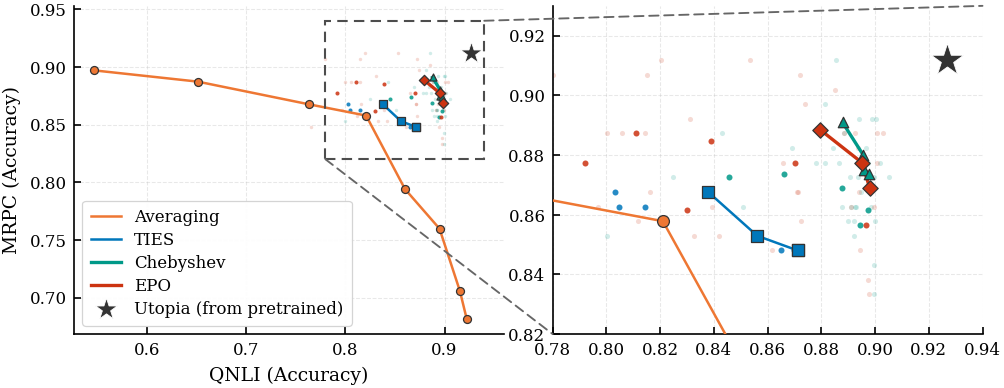

In [14]:
fig, axes = plot_pareto_with_zoom(
    methods_config=METHODS_2TASK,
    task_x="qnli",
    task_y="mrpc",
    zoom_rect=(0.78, 0.82, 0.94, 0.94),
    zoom_xlim=(0.78, 0.94),
    zoom_ylim=(0.82, 0.93),
)
save_fig(fig, "pareto_qnli_mrpc")
plt.show()

In [15]:
# Animation frames: progressive method reveal
# Produces 4 PDFs with identical axes for use as presentation animation frames.
# Edit ANIM_ZOOM_* to adjust the zoom window (shared across all frames).

ANIM_ZOOM_RECT = (0.78, 0.82, 0.94, 0.94)
ANIM_ZOOM_XLIM = (0.78, 0.94)
ANIM_ZOOM_YLIM = (0.82, 0.93)

# Derive outer axis limits from the full dataset (all 4 methods) so every
# frame uses the exact same scale as the original two-task plot.
_full_fig, (_ax_ref, _) = plot_pareto_with_zoom(
    methods_config=METHODS_2TASK, task_x="qnli", task_y="mrpc",
    zoom_rect=ANIM_ZOOM_RECT, zoom_xlim=ANIM_ZOOM_XLIM, zoom_ylim=ANIM_ZOOM_YLIM,
)
_ANIM_XLIM = _ax_ref.get_xlim()
_ANIM_YLIM = _ax_ref.get_ylim()
plt.close(_full_fig)

_ANIM_STEPS = [
    ["Averaging"],
    ["Averaging", "TIES"],
    ["Averaging", "TIES", "Chebyshev"],
    ["Averaging", "TIES", "Chebyshev", "EPO"],
]

_STEP_NAMES = ["averaging", "averaging_ties", "averaging_ties_cheb", "all_methods"]

for _methods, _name in zip(_ANIM_STEPS, _STEP_NAMES):
    _cfg = {m: METHODS_2TASK[m] for m in _methods}
    _fig, _ = plot_pareto_with_zoom(
        methods_config=_cfg,
        task_x="qnli",
        task_y="mrpc",
        zoom_rect=ANIM_ZOOM_RECT,
        zoom_xlim=ANIM_ZOOM_XLIM,
        zoom_ylim=ANIM_ZOOM_YLIM,
        xlim=_ANIM_XLIM,
        ylim=_ANIM_YLIM,
    )
    save_fig(_fig, f"anim_pareto_{_name}")
    plt.close(_fig)
    print(f"saved anim_pareto_{_name}")

Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging.png
saved anim_pareto_averaging
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging_ties.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging_ties.png
saved anim_pareto_averaging_ties
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging_ties_cheb.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_averaging_ties_cheb.png
saved anim_pareto_averaging_ties_cheb
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\anim_pareto_all_methods.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outp

---
## Plot 2 Performance Heatmap (4-Task)

In [623]:
def _fmt_pref(pv):
    """'[0.70, 0.10, 0.10, 0.10]' -> '(.7, .1, .1, .1)'"""
    nums = [float(x) for x in pv.strip("[]").split(",")]
    parts = []
    for n in nums:
        s = f"{n:.2f}".lstrip("0")
        s = s.rstrip("0").rstrip(".") if "." in s else s
        parts.append(s or "0")
    return "(" + ", ".join(parts) + ")"


def _load_heatmap_matrix(run_dir, task_metrics, task_order):
    """Load CSV and pivot into (preference_vectors x tasks) DataFrame."""
    _tm = task_metrics or TASK_METRICS
    csv_path = PROJECT_ROOT / run_dir / "visualizations" / "comprehensive_results.csv"
    df = pd.read_csv(csv_path)
    df = df[~df["source"].str.startswith("finetuned")].copy()
    available   = df["task"].unique().tolist()
    _task_order = [t for t in (task_order or list(_tm.keys())) if t in available]
    pref_vecs   = list(dict.fromkeys(df["preference_vector"].tolist()))

    def _pref_sort_key(pv):
        try:
            w = [float(x) for x in pv.strip("[]").split(",")]
            mx = max(w)
            all_equal = all(abs(x - w[0]) < 1e-9 for x in w)
            focused   = mx > 0.5          # one clearly dominant task
            if all_equal:
                return (0, 0, 0)          # uniform first
            elif focused:
                return (1, w.index(mx), 0) # focused: sorted by dominant task index
            else:
                return (2, w.index(mx), -mx) # balanced last
        except ValueError:
            return (3, 0, 0)              # non-numeric entries go last

    pref_vecs = sorted(pref_vecs, key=_pref_sort_key)
    records = []
    for pref in pref_vecs:
        row = {"pref": pref}
        for task in _task_order:
            metric = _tm.get(task, "accuracy")
            vals = df[(df["preference_vector"] == pref) & (df["task"] == task)][metric]
            row[task] = float(vals.iloc[0]) if len(vals) > 0 else np.nan
        records.append(row)
    return pd.DataFrame(records).set_index("pref")[_task_order]


def heatmap_global_range(run_dirs, task_metrics=None, task_order=None):
    """
    Compute per-metric (vmin, vmax) across all given run directories.
    Returns dict: {metric_name: (vmin, vmax)}.
    Use this to get a consistent, separate scale per metric type.
    """
    _tm = task_metrics or TASK_METRICS
    metric_vals = {}
    for rd in run_dirs:
        mat = _load_heatmap_matrix(rd, _tm, task_order)
        for task in mat.columns:
            metric = _tm.get(task, "accuracy")
            metric_vals.setdefault(metric, []).extend(mat[task].dropna().tolist())
    return {m: (float(np.min(vs)), float(np.max(vs))) for m, vs in metric_vals.items()}


_METRIC_SHORT = {"accuracy": "Acc.", "mcc": "MCC", "f1_macro": "F1",
                 "cohen_kappa": "k", "f1_weighted": "F1w"}


def plot_performance_heatmap(
    run_dir,
    task_metrics=None,
    task_order=None,
    cmap="RdYlGn",
    metric_ranges=None,   # {metric: (vmin, vmax)} â€” use heatmap_global_range()
    ax=None,
    figsize=None,
    fmt=".3f",
    pref_labels=None,
    show_yticks=True,
    show_colorbar=True,
    metric_cmaps=None,  # {metric: cmap_name} — overrides cmap per metric
):
    """
    Heatmap of per-task metric across all preference vectors for one method run.

    Each task column is coloured with its own metric's range (from metric_ranges),
    so MCC and accuracy are never conflated into a single scale.

    Parameters
    ----------
    run_dir : str
    task_metrics, task_order, cmap, ax, figsize, fmt, pref_labels : see config.
    metric_ranges : dict {metric_name: (vmin, vmax)}
        Shared scale per metric. Build with heatmap_global_range().
        If None, computed from this run's data only.
    show_yticks : bool   â€” False on non-leftmost panels.
    show_colorbar : bool â€” False when caller attaches a shared colorbar.

    Returns
    -------
    fig, ax, meshes  â€” meshes is dict {metric: last pcolormesh of that metric}
                       needed to attach external colorbars.
    """
    _tm   = task_metrics or TASK_METRICS
    _pref = pref_labels  or {}
    mat   = _load_heatmap_matrix(run_dir, _tm, task_order)
    data  = mat.values
    n_rows, n_cols = data.shape

    # Per-metric ranges â€” copy to avoid mutating the caller's shared dict
    _ranges = dict(metric_ranges) if metric_ranges else {}
    for task in mat.columns:
        metric = _tm.get(task, "accuracy")
        if metric not in _ranges:
            col = mat[task].dropna().values
            _ranges[metric] = (float(col.min()), float(col.max()))

    # Labels
    y_labels = [_pref.get(pv, _fmt_pref(pv)) for pv in mat.index]
    x_labels = []
    for t in mat.columns:
        name = TASK_AXIS_LABELS.get(t, t.upper()).split(" (")[0]
        met  = _METRIC_SHORT.get(_tm.get(t, "accuracy"), _tm.get(t, "accuracy"))
        x_labels.append(f"{name}\n({met})")

    # Figure
    standalone = ax is None
    if standalone:
        cell_w = 1.3
        cell_h = 0.34
        w = max(3.5, cell_w * n_cols + (1.5 if show_yticks else 0.3))
        h = max(2.0, cell_h * n_rows + 0.8)
        fig, ax = plt.subplots(figsize=figsize or (w, h), dpi=FIGURE_DPI)
    else:
        fig = ax.figure

    # Draw each column separately so MCC and accuracy use independent scales
    meshes = {}
    for j, task in enumerate(mat.columns):
        metric       = _tm.get(task, "accuracy")
        vmin_c, vmax_c = _ranges[metric]
        col_data     = data[:, j:j+1]                  # shape (n_rows, 1)
        _cmap = (metric_cmaps or {}).get(metric, cmap)
        mesh = ax.pcolormesh(
            [j, j + 1],                                 # x edges
            np.arange(n_rows + 1),                      # y edges
            col_data,
            cmap=_cmap, vmin=vmin_c, vmax=vmax_c,
            edgecolors="white", linewidth=0.8,
        )
        meshes[metric] = mesh                           # keep last mesh per metric

    ax.invert_yaxis()
    ax.set_xlim(0, n_cols)

    # Cell value annotations
    # Accuracy → display as 'xx.x' (percentage without % sign; label is on colorbar)
    # MCC → display as '.3f' decimal
    PCT_METRICS = {"accuracy", "f1_macro", "f1_weighted", "f1_micro",
                   "precision_macro", "recall_macro"}
    for i in range(n_rows):
        for j, task in enumerate(mat.columns):
            val = data[i, j]
            if np.isnan(val):
                continue
            metric       = _tm.get(task, "accuracy")
            vmin_c, vmax_c = _ranges[metric]
            rel = (val - vmin_c) / (vmax_c - vmin_c + 1e-9)
            # Recompute cmap for THIS column (not the last loop value of _cmap)
            col_cmap = (metric_cmaps or {}).get(metric, cmap)
            rgba = mpl.colormaps[col_cmap](rel)
            lum  = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if lum < 0.45 else "0.12"
            if metric in PCT_METRICS:
                label = f"{val * 100:.1f}"
            else:
                label = format(val, fmt)
            ax.text(j + 0.5, i + 0.5, label,
                    ha="center", va="center", fontsize=7.5, color=text_color)

    # Ticks
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(x_labels, fontsize=7.5)          # horizontal, centred on column
    ax.set_yticks(np.arange(n_rows) + 0.5)
    if show_yticks:
        ax.set_yticklabels(
            y_labels, fontsize=7,
            rotation=35, ha="right", va="center",
            rotation_mode="anchor",                     # pivot at the tick point
        )
        ax.set_ylabel("Preference vector", fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.spines[:].set_visible(False)

    if show_colorbar:
        # Single colorbar (works best for standalone / single-metric heatmaps)
        cb = fig.colorbar(next(iter(meshes.values())), ax=ax,
                          shrink=0.88, pad=0.03, aspect=22)
        cb.ax.tick_params(labelsize=7, length=2)
        cb.outline.set_linewidth(0.5)

    if standalone:
        fig.tight_layout(pad=0.4)
    return fig, ax, meshes


Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\heatmaps_4task.pdf
Saved: C:\Users\robin\Programmieren\ETHZ-Kurse\Bachelor Thesis SML\outputs\thesis_plots\heatmaps_4task.png


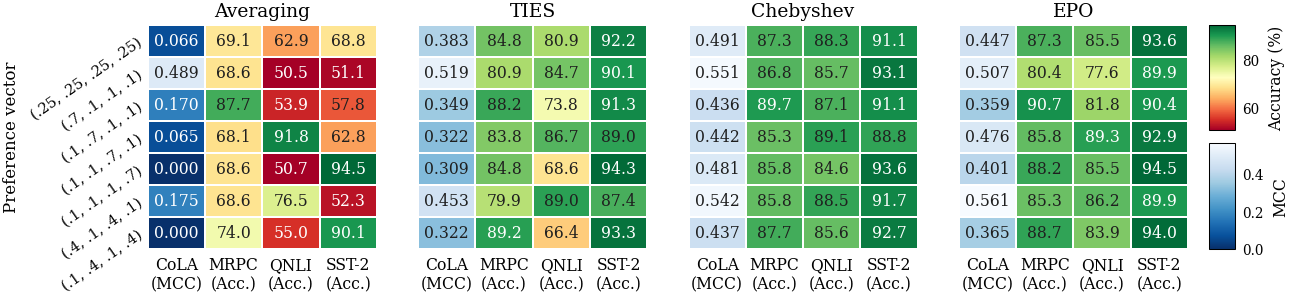

In [624]:
import matplotlib.ticker as mticker

# Consistent per-metric colorscale across all methods
metric_ranges = heatmap_global_range(list(HEATMAP_RUNS_4TASK.values()))

n_methods = len(HEATMAP_RUNS_4TASK)
fig, axes = plt.subplots(
    1, n_methods,
    figsize=(9.5, 2.2),
    dpi=FIGURE_DPI,
    # NOTE: no sharey â€” label visibility is managed per-panel inside the function
)

all_meshes = {}
for i, (ax, (method_name, run_dir)) in enumerate(zip(axes, HEATMAP_RUNS_4TASK.items())):
    _, _, meshes = plot_performance_heatmap(
        run_dir, ax=ax,
        metric_ranges=metric_ranges,
        metric_cmaps=METRIC_CMAPS,
        show_yticks=(i == 0),
        show_colorbar=False,
    )
    ax.set_title(method_name, fontsize=9, pad=4)
    all_meshes.update(meshes)

# Reserve right margin for two stacked colorbars, add spacing between panels
fig.subplots_adjust(left=0.14, right=0.87, bottom=0.20, top=0.88, wspace=0.18)

# Place two colorbars: Accuracy (top) and MCC (bottom)
pos = axes[-1].get_position()
gap   = 0.04          # gap between the two bars
bar_h = (pos.height - gap) / 2
bar_x = pos.x1 + 0.015
bar_w = 0.018

if "accuracy" in all_meshes:
    cax = fig.add_axes([bar_x, pos.y0 + bar_h + gap, bar_w, bar_h])
    cb  = fig.colorbar(all_meshes["accuracy"], cax=cax)
    cb.set_label("Accuracy (%)", fontsize=7.5)
    cb.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}"))
    cb.ax.tick_params(labelsize=6.5, length=2)
    cb.outline.set_linewidth(0.5)

if "mcc" in all_meshes:
    cax = fig.add_axes([bar_x, pos.y0, bar_w, bar_h])
    cb  = fig.colorbar(all_meshes["mcc"], cax=cax)
    cb.set_label("MCC", fontsize=7.5)
    cb.ax.tick_params(labelsize=6.5, length=2)
    cb.outline.set_linewidth(0.5)

save_fig(fig, "heatmaps_4task")
plt.show()


---
## Table — 2-Task Benchmark (Appendix)

In [600]:
def build_2task_latex_table(
    methods_config,
    task_x="qnli",
    task_y="mrpc",
    task_metrics=None,
    caption=(
        "Per-preference-vector accuracy (\\%) on the 2-task benchmark "
        "(QNLI--MRPC). Values show the mean across seeds; "
        "$\\pm$ denotes one standard deviation (omitted for single-seed runs)."
    ),
    label="tab:2task_full",
):
    """Print a booktabs LaTeX table ready to paste into Overleaf."""
    _tm = task_metrics or TASK_METRICS
    tasks = [task_x, task_y]
    task_labels = {"qnli": "QNLI", "mrpc": "MRPC", "cola": "CoLA", "sst2": "SST-2"}

    # Collect per-method aggregated stats
    method_stats = {}
    all_pvecs = None
    for method, run_dirs in methods_config.items():
        data = load_method_data(run_dirs, task_metrics=_tm)
        piv = (
            data[data["task"].isin(tasks)]
            .pivot_table(index=["preference_vector", "seed"],
                         columns="task", values="metric_value")
            .reset_index()
        )
        piv.columns.name = None
        agg = piv.groupby("preference_vector")[tasks].agg(["mean", "std"]).reset_index()
        agg.columns = (["preference_vector"]
                       + [f"{t}_{s}" for t in tasks for s in ["mean", "std"]])
        agg["n_seeds"] = piv.groupby("preference_vector")["seed"].nunique().values
        agg = agg.sort_values(f"{task_x}_mean").reset_index(drop=True)
        method_stats[method] = agg
        if all_pvecs is None:
            all_pvecs = agg["preference_vector"].tolist()

    def fmt_cell(row, task):
        mu  = row[f"{task}_mean"] * 100
        std = row[f"{task}_std"]
        n   = int(row["n_seeds"])
        if n > 1 and not (std != std):   # show \pm even when std=0; std!=std catches NaN
            return f"${mu:.1f} \\pm {std * 100:.1f}$"
        return f"${mu:.1f}$"

    col_spec = "l" + " cc" * len(methods_config)
    L = []
    L.append("\\begin{table}[htbp]")
    L.append("  \\centering")
    L.append("  \\small")
    L.append(f"  \\caption{{{caption}}}")
    L.append(f"  \\label{{{label}}}")
    L.append(f"  \\begin{{tabular}}{{{col_spec}}}")
    L.append("    \\toprule")

    # Method header
    hdr = ["Pref.\\ vector"] + [
        f"\\multicolumn{{2}}{{c}}{{{m}}}" for m in methods_config
    ]
    L.append("    " + " & ".join(hdr) + " \\\\")

    # Cmidrules
    rules = []
    for i in range(len(methods_config)):
        c0 = 2 + i * 2
        rules.append(f"\\cmidrule(lr){{{c0}-{c0 + 1}}}")
    L.append("    " + " ".join(rules))

    # Task sub-header
    sub = [""] + [task_labels.get(t, t.upper())
                  for _ in methods_config for t in tasks]
    L.append("    " + " & ".join(sub) + " \\\\")
    L.append("    \\midrule")

    # Data rows — bold the best mean per (preference vector, task)
    for pv in all_pvecs:
        pv_label = _fmt_pref(pv)
        # Find best mean per task across methods
        best = {}
        for t in tasks:
            vals = []
            for agg in method_stats.values():
                r = agg[agg["preference_vector"] == pv]
                if len(r):
                    vals.append(r.iloc[0][f"{t}_mean"])
            best[t] = max(vals) if vals else None

        cells = [pv_label]
        for method, agg in method_stats.items():
            r = agg[agg["preference_vector"] == pv]
            if len(r) == 0:
                cells += ["-", "-"]
            else:
                r = r.iloc[0]
                for t in tasks:
                    cell = fmt_cell(r, t)
                    if best[t] is not None and abs(r[f"{t}_mean"] - best[t]) < 1e-9:
                        # cell is $...$; strip delimiters so \\mathbf wraps the content
                        cell = "$\\mathbf{" + cell[1:-1] + "}$"
                    cells.append(cell)
        L.append("    " + " & ".join(cells) + " \\\\")

    L.append("    \\bottomrule")
    L.append("  \\end{tabular}")
    L.append("\\end{table}")
    return "\n".join(L)


tex = build_2task_latex_table(METHODS_2TASK)
print(tex)


\begin{table}[htbp]
  \centering
  \small
  \caption{Per-preference-vector accuracy (\%) on the 2-task benchmark (QNLI--MRPC). Values show the mean across seeds; $\pm$ denotes one standard deviation (omitted for single-seed runs).}
  \label{tab:2task_full}
  \begin{tabular}{l cc cc cc cc}
    \toprule
    Pref.\ vector & \multicolumn{2}{c}{Averaging} & \multicolumn{2}{c}{TIES} & \multicolumn{2}{c}{Chebyshev} & \multicolumn{2}{c}{EPO} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
     & QNLI & MRPC & QNLI & MRPC & QNLI & MRPC & QNLI & MRPC \\
    \midrule
    (.9, .1) & $54.6$ & $\mathbf{89.7}$ & $80.3$ & $86.8$ & $\mathbf{86.1 \pm 2.4}$ & $87.9 \pm 1.4$ & $79.6 \pm 2.7$ & $86.8 \pm 2.0$ \\
    (.8, .2) & $65.2$ & $\mathbf{88.7}$ & $80.5$ & $86.3$ & $\mathbf{88.0 \pm 1.2}$ & $87.4 \pm 1.0$ & $80.9 \pm 1.9$ & $88.1 \pm 1.6$ \\
    (.7, .3) & $76.3$ & $86.8$ & $81.4$ & $86.3$ & $\mathbf{88.9 \pm 0.7}$ & $\mathbf{88.4 \pm 1.9}$ & $84.5 \pm 0.8$ & $87.6 